# Definitions

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils


In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="3x2pt"

path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ggl_exclude=[[6,0],[7,0],[7,1]]

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
lmax = 100000


In [4]:
As_1e9 = 2.1
ns = 0.96605
H0 = 67.32
omegab = 0.04
omegam = 0.3
mnu = 0.06
w = -1.0
w0pwa = -1.0
roman_A1_1 = 0.6
roman_A1_2 = -1.5
roman_DZ_S1 = 0.0
roman_DZ_S2 = 0.0
roman_DZ_S3 = 0.0
roman_DZ_S4 = 0.0
roman_DZ_S5 = 0.0
roman_DZ_S6 = 0.0
roman_DZ_S7 = 0.0
roman_DZ_S8 = 0.0
roman_M1 = 0.0
roman_M2 = 0.0
roman_M3 = 0.0
roman_M4 = 0.0
roman_M5 = 0.0
roman_M6 = 0.0
roman_M7 = 0.0
roman_M8 = 0.0
roman_DZ_L1 = 0.0
roman_DZ_L2 = 0.0
roman_DZ_L3 = 0.0
roman_DZ_L4 = 0.0
roman_DZ_L5 = 0.0
roman_DZ_L6 = 0.0
roman_DZ_L7 = 0.0
roman_DZ_L8 = 0.0
roman_B1_1 = 1.18
roman_B1_2 = 1.40
roman_B1_3 = 1.55
roman_B1_4 = 1.71
roman_B1_5 = 1.90
roman_B1_6 = 2.15
roman_B1_7 = 2.52
roman_B1_8 = 2.44
roman_PM1 = 0.0
roman_PM2 = 0.0
roman_PM3 = 0.0
roman_PM4 = 0.0
roman_PM5 = 0.0
roman_PM6 = 0.0
roman_PM7 = 0.0
roman_PM8 = 0.0

In [5]:
# Init Cosmolike for the masked 3x2pt data vector (the same init the
# chi2 section of EXAMPLE_EVALUATE2.ipynb performs)
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))

allsims = ini.relativeFileName('all_sims_hdf5_file')

ci.initial_setup()

ci.init_ggl_exclude(np.array(ggl_exclude).flatten())

ci.init_probes(possible_probes = CLprobe)

ci.init_binning(int(ini.int("n_theta")), 
                ini.float("theta_min_arcmin"), 
                ini.float("theta_max_arcmin"))

ci.init_cosmo_runmode(is_linear = False)

ci.init_IA( ia_model = int(IA_model), 
            ia_redshift_evolution = int(IA_redshift_evolution),
            ia_code = int(IA_code))

ci.init_redshift_distributions_from_files(
      lens_multihisto_file=ini.relativeFileName('nz_lens_file'),
      lens_ntomo=int(ini.int("lens_ntomo")), 
      source_multihisto_file=ini.relativeFileName('nz_source_file'),
      source_ntomo=int(ini.int("source_ntomo")))

ci.init_data_real(ini.relativeFileName('cov_file'), 
                  ini.relativeFileName('mask_file'), 
                  ini.relativeFileName('data_file'))

ci.init_bias(bias_model=[0,0,0,1,0,0])

ci.init_ntable_lmax(lmax=int(lmax))

ci.init_accuracy_boost(1.0, int(1))


[2026-09-22 15:38:47.626] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2026-09-22 15:38:47.626] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded
[2026-09-22 15:38:47.626] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


# The baryonic feedback methods of the `bfmt` theory block

The `bfmt` theory block (`external_modules/code/baryon_suppression`) implements seven ways to compute the suppression $S(k, z) = P_{\rm hydro}/P_{\rm DMO}$ of the nonlinear matter power spectrum: three semi-analytical SP(k) baryon-fraction relations and four emulators. Instead of re-implementing any of them here, this notebook drives the block itself through a minimal Cobaya model (CAMB + `bfmt` + the unit likelihood), requesting the suppression on this notebook's own $(k, z)$ interpolation grid - the same product, produced by the same code, that the Cosmolike likelihoods consume in an MCMC run.

In [6]:
# One entry per feedback method: (label, bfmt options, fixed parameter
# point). The SP(k) points are pyspk's documented examples; the emulator
# points are the fiducial values quoted in the example yamls. BACCOemu
# is commented out on this project: its omega_baryon training box
# starts at 0.04001, exactly above this notebook's omegab = 0.04, so
# the block (correctly) rejects the fiducial.
BARYON_METHODS = [
    ("SP(k) power law", {"baryon_model": 1, "spk_fb_model": 1},
     {"fb_a_spk": 0.4, "fb_pow_spk": 0.3}),
    ("SP(k) Akino et al. 2022", {"baryon_model": 1, "spk_fb_model": 2},
     {"alpha_spk": 4.189, "beta_spk": 1.273, "gamma_spk": 0.298}),
    # this point matches the Akino relation's amplitude at the pivot
    # and stays inside SP(k)'s calibrated baryon-fraction band over
    # the full z grid; pyspk's documented example (0.3, 1.1, 0.2,
    # 0.5) exits the band at z >~ 1.4, and the block then falls back
    # to unity for those redshifts
    ("SP(k) double power law", {"baryon_model": 1, "spk_fb_model": 3},
     {"epsilon_spk": 0.66, "alpha_spk": 0.35, "beta_spk": 0.2,
      "gamma_spk": 0.3}),
    ("BCEmu", {"baryon_model": 2},
     {"log10Mc_bcemu": 13.32, "mu_bcemu": 0.93, "thej_bcemu": 4.235,
      "gamma_bcemu": 2.25, "delta_bcemu": 6.40, "eta_bcemu": 0.15,
      "deta_bcemu": 0.14}),
    ("Flamingo", {"baryon_model": 3},
     {"fgas_sigma_flamingo": 0.0, "mstar_sigma_flamingo": 0.0,
      "jet_frac_flamingo": 0.0}),
    #("BACCOemu", {"baryon_model": 4},
    # {"M_c_baccoemu": 14.0, "eta_baccoemu": -0.3, "beta_baccoemu": -0.22,
    #  "M1_z0_cen_baccoemu": 10.5, "theta_inn_baccoemu": -0.86}),
    ("BCemu2025", {"baryon_model": 5},
     {"Theta_co_bcemu25": 0.3, "log10Mc_bcemu25": 13.1, "mu_bcemu25": 1.0,
      "delta_bcemu25": 6.0, "eta_bcemu25": 0.10, "deta_bcemu25": 0.22,
      "Nstar_bcemu25": 0.028}),
]


In [7]:
def get_baryon_suppression(theory_options, point, z_grid, log10k_grid):
    """Suppression S(k, z) from the bfmt theory block, on our grid.

    Builds a minimal Cobaya model (CAMB + bfmt + the unit likelihood),
    requests the baryon_suppression product at the notebook's own
    interpolation grid (k in 1/Mpc, as the Cosmolike likelihoods send
    it; the block converts to h/Mpc internally), evaluates it at this
    notebook's fiducial cosmology, and returns {z: S array over k}.
    """
    from cobaya.model import get_model
    info = {
        "likelihood": {"one": None},
        "theory": {
            # no "path" here: the notebook already imported camb (cell
            # 2), and cobaya accepts the loaded module as is; a path
            # request would fail the loaded-from check
            "camb": {"extra_args": {"halofit_version": "takahashi",
                                    "dark_energy_model": "ppf"}},
            "bfmt": dict({"python_path": os.environ["ROOTDIR"]
                          + "/external_modules/code/baryon_suppression"},
                         **theory_options),
        },
        "params": dict({
            "As": {"value": As_1e9*1e-9},
            "ns": ns, "H0": H0, "mnu": mnu, "tau": 0.0543,
            "w": w,
            "ombh2": omegab*(H0/100)**2,
            "omch2": (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708,
            "omegam": {"derived": True, "latex": r"\Omega_m"},
        }, **point),
        "debug": 50,
    }
    model = get_model(info)
    model.add_requirements({"baryon_suppression": {
        "z": z_grid, "k": np.power(10.0, log10k_grid)}})
    model.logposterior({})
    return model.provider.get_baryon_suppression()


In [8]:
def compute_probes(sup = None):
    """The four 3x2pt probes and the masked data vector, with optional
    baryonic suppression folded into the nonlinear power spectrum.

    sup = None computes the dark-matter-only prediction; otherwise sup
    is the {z: S array} dictionary from get_baryon_suppression, applied
    exactly as the Cosmolike likelihoods apply it:
    lnPNL[i :: len(z_grid)] += ln S(z_i).
    """
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL,
     G_growth, z_interp_1D, chi) = cnu.get_camb_cosmology(
        omegam=omegam, omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9,
        w=w, w0pwa=w0pwa, mnu=mnu, kmax=7.5, k_per_logint=10,
        CAMBAccuracyBoost=CAMBAccuracyBoost,
        non_linear_emul=non_linear_emul)
    lnPNL = np.array(lnPNL, copy=True)
    if sup is not None:
        for i, z_val in enumerate(z_interp_2D):
            # every k row of redshift z_i sits at stride len(z) in the
            # flattened table, the layout set_cosmology expects
            lnPNL[i :: len(z_interp_2D)] += np.log(sup[z_val])
    ci.init_ntable_lmax(int(100000 + 20000*(1.0-1)))
    ci.init_accuracy_boost(1.0, 0)
    ci.set_cosmology(omegam=omegam, H0=H0,
                     log10k_2D=log10k_interp_2D, z_2D=z_interp_2D,
                     lnP_linear=lnPL, lnP_nonlinear=lnPNL,
                     G=G_growth, z_1D=z_interp_1D, chi=chi)
    ci.set_nuisance_shear_calib(
        M=[roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6,
           roman_M7, roman_M8])
    ci.set_nuisance_shear_photoz(
        bias=[roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4,
              roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8])
    ci.set_nuisance_clustering_photoz(
        bias=[roman_DZ_L1, roman_DZ_L2, roman_DZ_L3, roman_DZ_L4,
              roman_DZ_L5, roman_DZ_L6, roman_DZ_L7, roman_DZ_L8])
    ci.set_nuisance_ia(A1=[roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0],
                       A2=[0, 0, 0, 0, 0, 0, 0, 0],
                       B_TA=[0, 0, 0, 0, 0, 0, 0, 0])
    ci.set_nuisance_bias(
        B1=[roman_B1_1, roman_B1_2, roman_B1_3, roman_B1_4, roman_B1_5,
            roman_B1_6, roman_B1_7, roman_B1_8],
        B2=[0, 0, 0, 0, 0, 0, 0, 0],
        B_MAG=[0, 0, 0, 0, 0, 0, 0, 0],
        B3nl=[0, 0, 0, 0, 0, 0, 0, 0],
        BK=[0, 0, 0, 0, 0, 0, 0, 0])
    ci.set_point_mass(PMV=[roman_PM1, roman_PM2, roman_PM3, roman_PM4,
                           roman_PM5, roman_PM6, roman_PM7, roman_PM8])
    ci.reset_bary_struct()
    ell = np.arange(25., 3000., 15.)
    (C_ss, tmp) = ci.C_ss_tomo_limber(l = ell)
    C_gs = ci.C_gs_tomo_limber(l = ell)
    (xip, xim) = ci.xi_pm_tomo()
    gt = ci.w_gammat_tomo()
    theta = ci.get_binning_real_space()
    dv = np.array(ci.compute_data_vector_masked())
    chi2 = ci.compute_chi2(dv)
    return {"ell": ell, "C_ss": C_ss, "C_gs": C_gs,
            "theta": theta, "xip": xip, "xim": xim, "gammat": gt,
            "dv": dv, "chi2": chi2,
            "z_grid": z_interp_2D, "log10k_grid": log10k_interp_2D}


# Compute the data vector without and with each feedback method

In [9]:
ref = compute_probes()
print("no feedback: chi2 = %.6f, data vector length = %d" % (ref["chi2"], len(ref["dv"])))

no feedback: chi2 = 0.070869, data vector length = 2115


In [10]:
results = {}
for label, theory_options, point in BARYON_METHODS:
    sup = get_baryon_suppression(theory_options, point,
                                 ref["z_grid"], ref["log10k_grid"])
    results[label] = compute_probes(sup = sup)
    print("%-28s chi2 = %10.4f" % (label, results[label]["chi2"]),
          flush=True)


SP(k) power law              chi2 =  1576.8068
SP(k) Akino et al. 2022      chi2 =   742.5750
SP(k) double power law       chi2 =   729.9003
BCEmu                        chi2 =   707.7771
Flamingo                     chi2 =   339.7644
Loading BCemu2025 models (backend='numpy')...


Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...BCemu2025 emulator is ready.
BCemu2025                    chi2 =   142.7423


# Print the data vectors

One row per masked entry: the dark-matter-only prediction first, then one column per feedback method. The chi2 line above each column shows how far each suppression pulls the prediction from the stored (feedback-free) data vector.

In [11]:
chains_dir = os.environ["ROOTDIR"] + "/projects/roman_real/chains"
os.makedirs(chains_dir, exist_ok=True)
table = np.column_stack([ref["dv"]] +
                        [results[label]["dv"] for label, _, _ in BARYON_METHODS])
header = "no_feedback " + " ".join(
    label.replace(" ", "_") for label, _, _ in BARYON_METHODS)
np.savetxt(chains_dir + "/EXAMPLE_EVALUATE3.datavectors",
           table, header=header)
print(header)
for i in (0, 1, 2, len(table)//2, len(table)-2, len(table)-1):
    print(("%6d" % i) + "".join(" %.6e" % v for v in table[i]))
print("full table saved to " + chains_dir + "/EXAMPLE_EVALUATE3.datavectors")


no_feedback SP(k)_power_law SP(k)_Akino_et_al._2022 SP(k)_double_power_law BCEmu Flamingo BCemu2025
     0 7.233803e-06 6.423946e-06 6.604150e-06 6.606466e-06 6.646460e-06 6.682865e-06 7.085108e-06
     1 5.861396e-06 5.271629e-06 5.403269e-06 5.404385e-06 5.434566e-06 5.501507e-06 5.804779e-06
     2 4.624032e-06 4.221731e-06 4.313143e-06 4.313550e-06 4.339011e-06 4.412992e-06 4.625507e-06
  1057 3.138240e-05 2.991688e-05 3.045757e-05 3.046248e-05 3.037546e-05 3.097582e-05 3.143192e-05
  2113 -3.016908e-05 -3.016917e-05 -3.017040e-05 -3.017041e-05 -3.016910e-05 -3.016686e-05 -3.017034e-05
  2114 -1.368289e-05 -1.368309e-05 -1.368364e-05 -1.368364e-05 -1.368292e-05 -1.368156e-05 -1.368358e-05
full table saved to /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/roman_real/chains/EXAMPLE_EVALUATE3.datavectors


# Cosmic shear with feedback: $C_\ell^{\rm EE}$ (Fourier space)

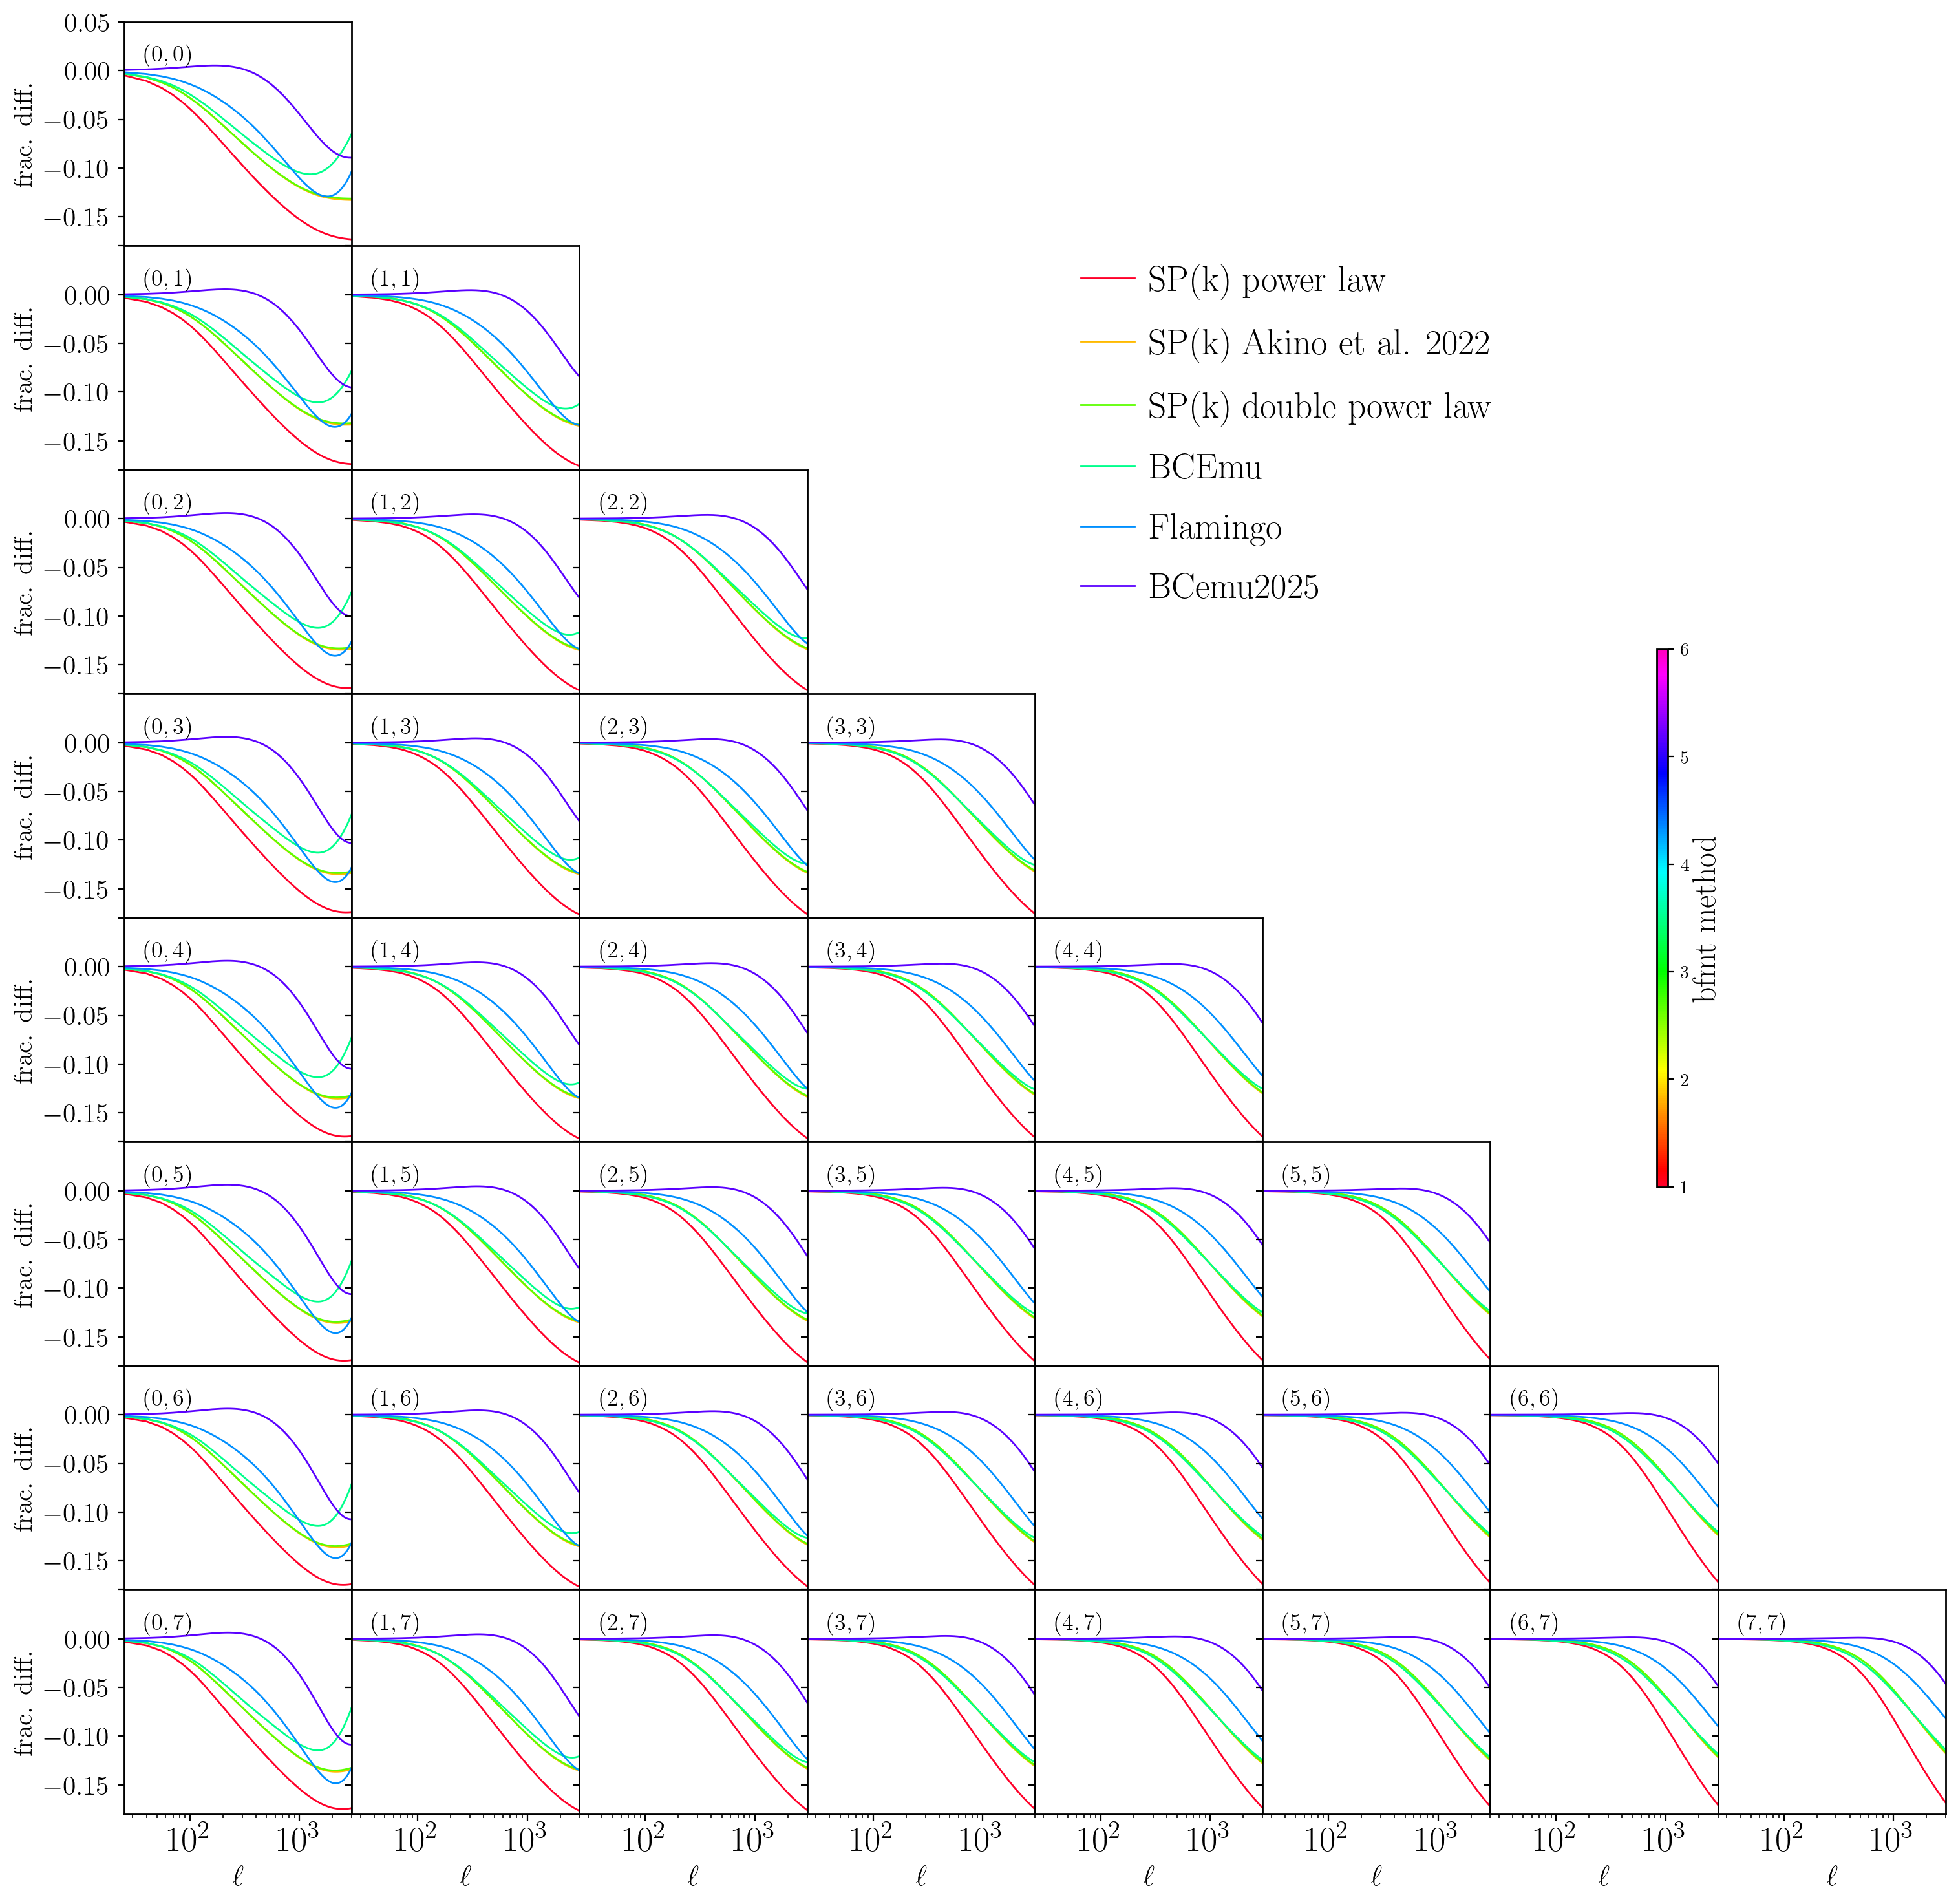

In [12]:
labels = [label for label, _, _ in BARYON_METHODS]

param = np.arange(1.0, 1.0 + len(labels))

C_ss_list = [results[label]["C_ss"] for label in labels]

cnu.plot_C_ss_tomo_limber(ell=ref["ell"],
                          C_ss=C_ss_list,
                          C_ss_ref=ref["C_ss"],
                          param=param,
                          lmin=25,
                          lmax=3000,
                          ylim=(0.82, 1.05),
                          colorbarlabel="bfmt method",
                          legend=labels,
                          figsize=(18, 18),
                          legendloc=(0.55, 0.68),
                          legendfontsize=20,
                          xaxisticklabelsize=20,
                          yaxisticklabelsize=15,
                          yaxislabelsize=15)

# Cosmic shear with feedback: $\xi_\pm(\theta)$ (real space)

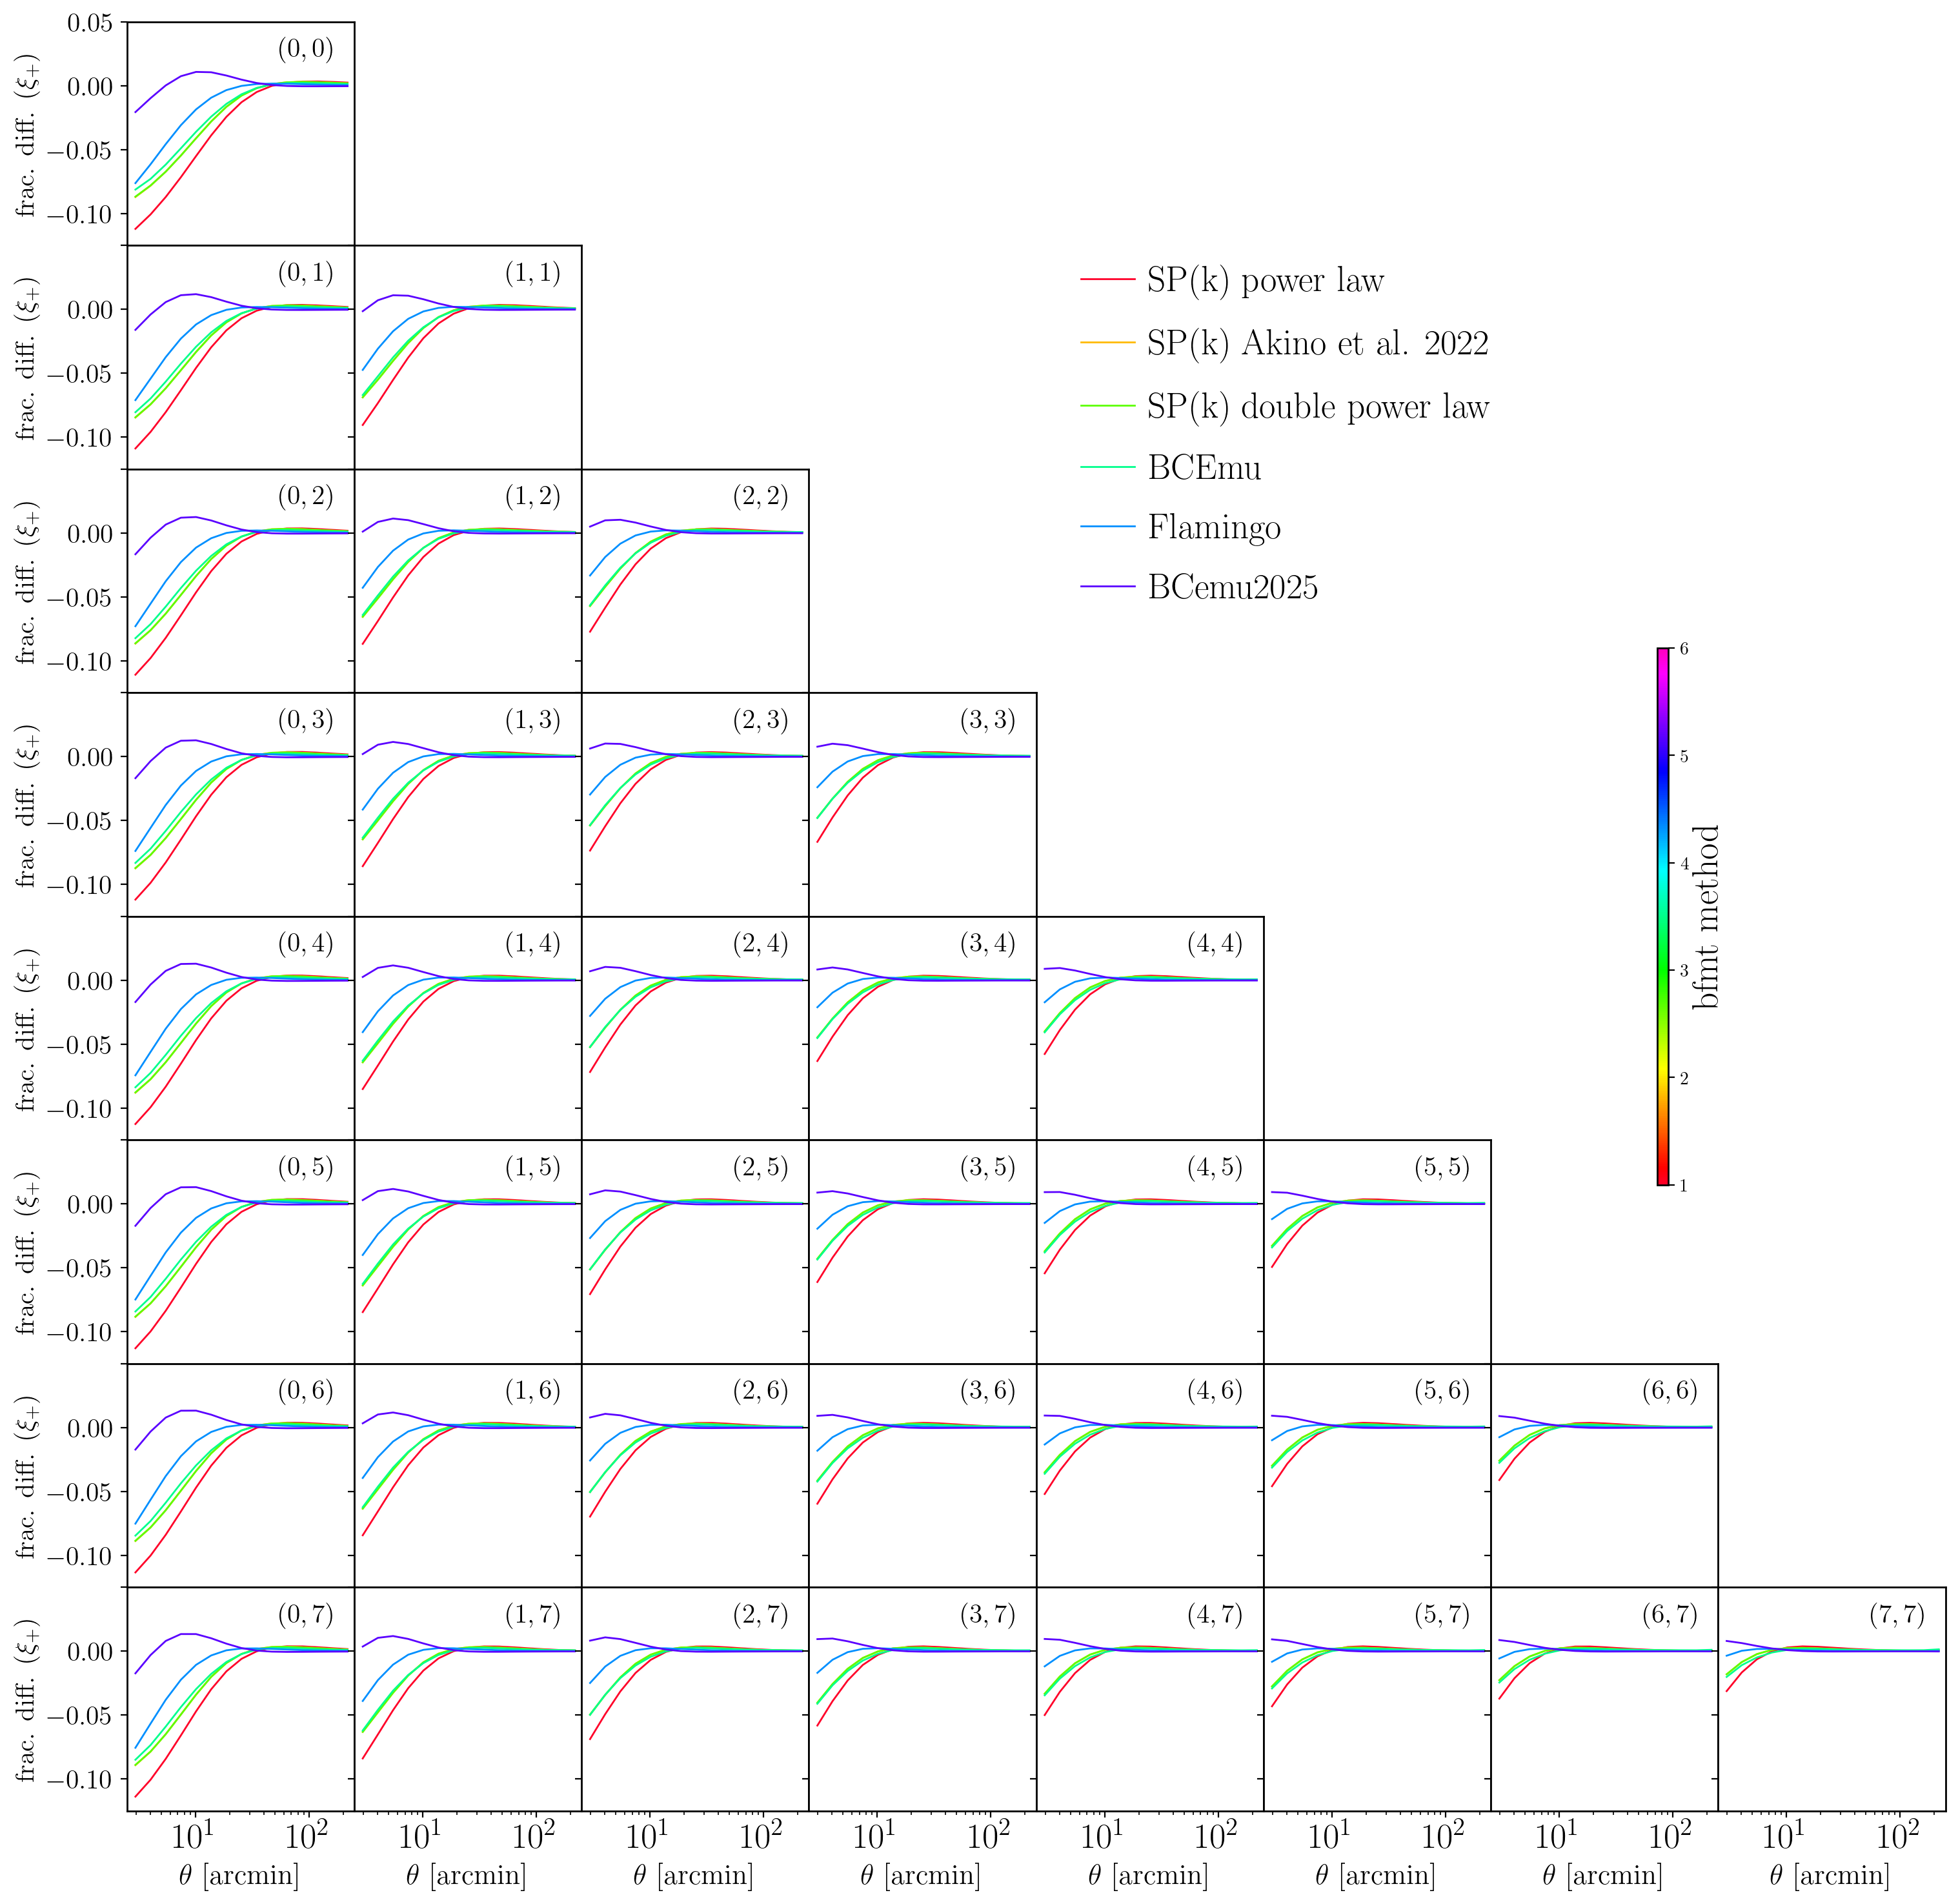

In [13]:
xi_list = [(results[label]["theta"], results[label]["xip"],
            results[label]["xim"]) for label in labels]

xi_ref = (ref["theta"], ref["xip"], ref["xim"])

cnu.plot_xi(pm=1,
            xi=xi_list,
            xi_ref=xi_ref,
            param=param,
            ylim=(0.875, 1.05),
            colorbarlabel="bfmt method",
            legend=labels,
            thetashow=[2.5, 250],
            legendloc=(0.55, 0.68),
            legendfontsize=20,
            xaxisticklabelsize=20,
            yaxisticklabelsize=15,
            yaxislabelsize=15)

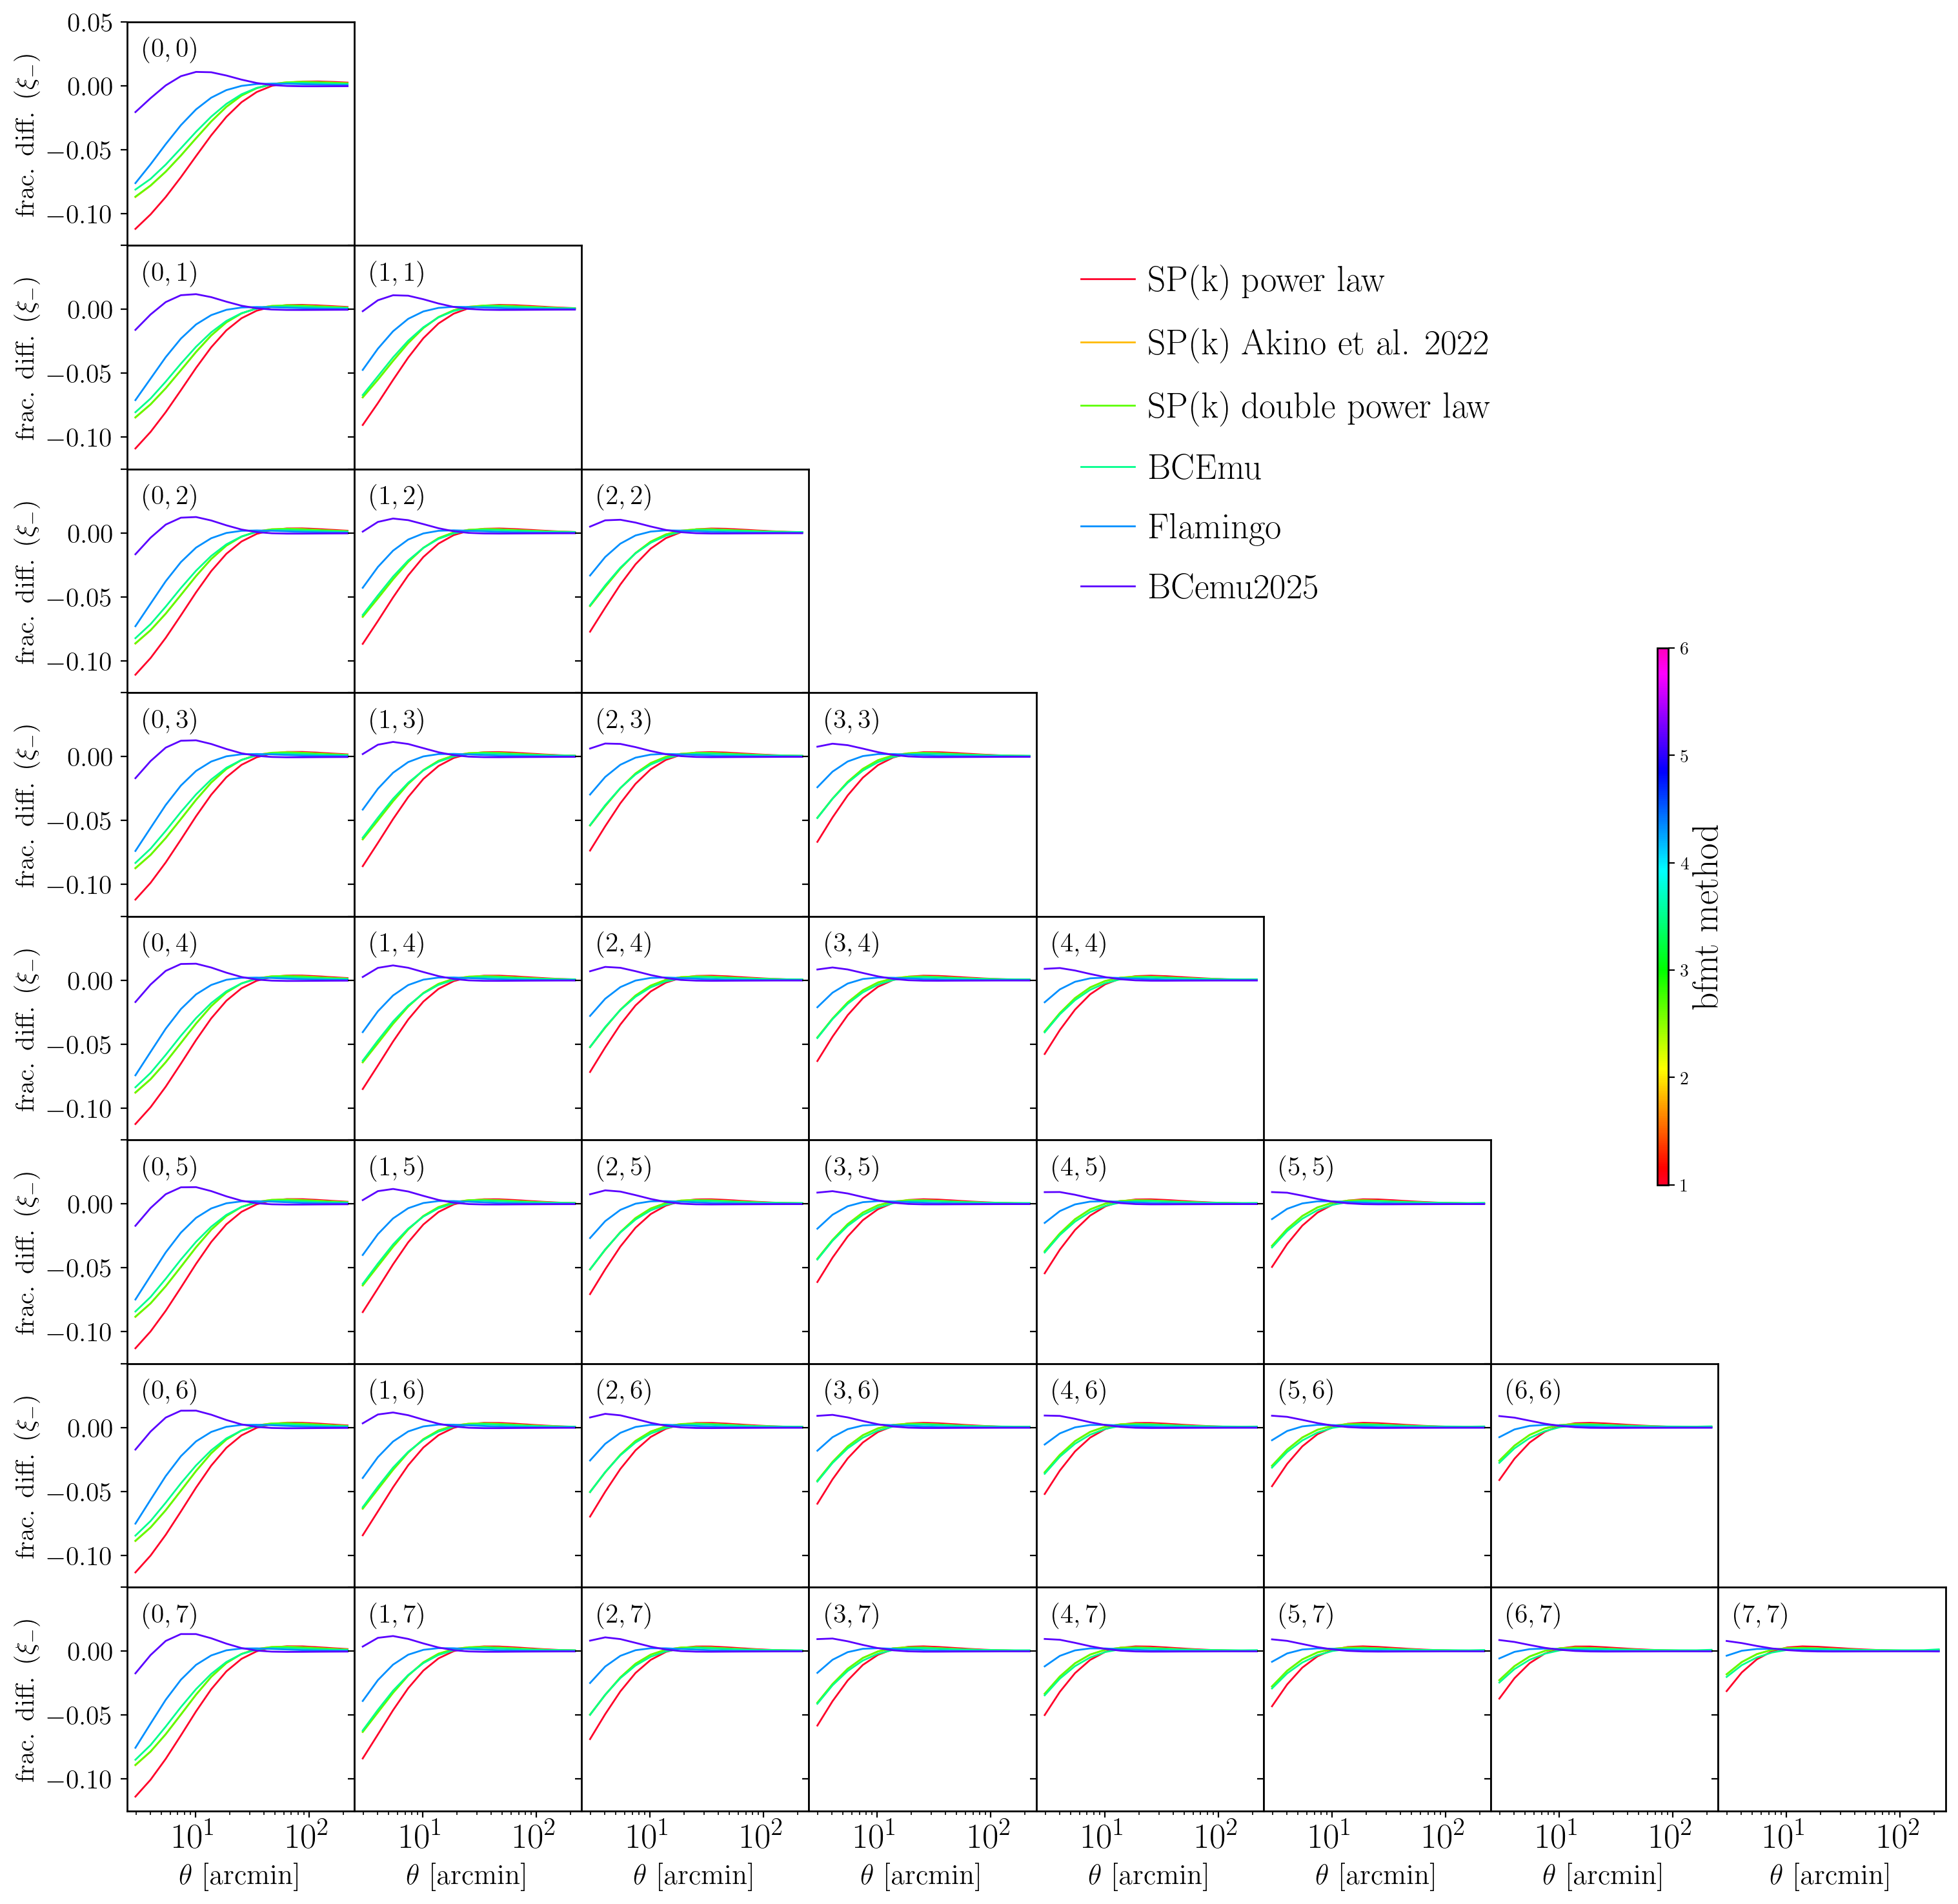

In [14]:
cnu.plot_xi(pm=0,
            xi=xi_list,
            xi_ref=xi_ref,
            param=param,
            ylim=(0.875, 1.05),
            colorbarlabel="bfmt method",
            legend=labels,
            figsize=(18, 18),
            thetashow=[2.5, 250],
            legendloc=(0.55, 0.68),
            legendfontsize=20,
            xaxisticklabelsize=20,
            yaxisticklabelsize=15,
            yaxislabelsize=15)

# Galaxy-galaxy lensing with feedback: $C_\ell^{gs}$ (Fourier space)

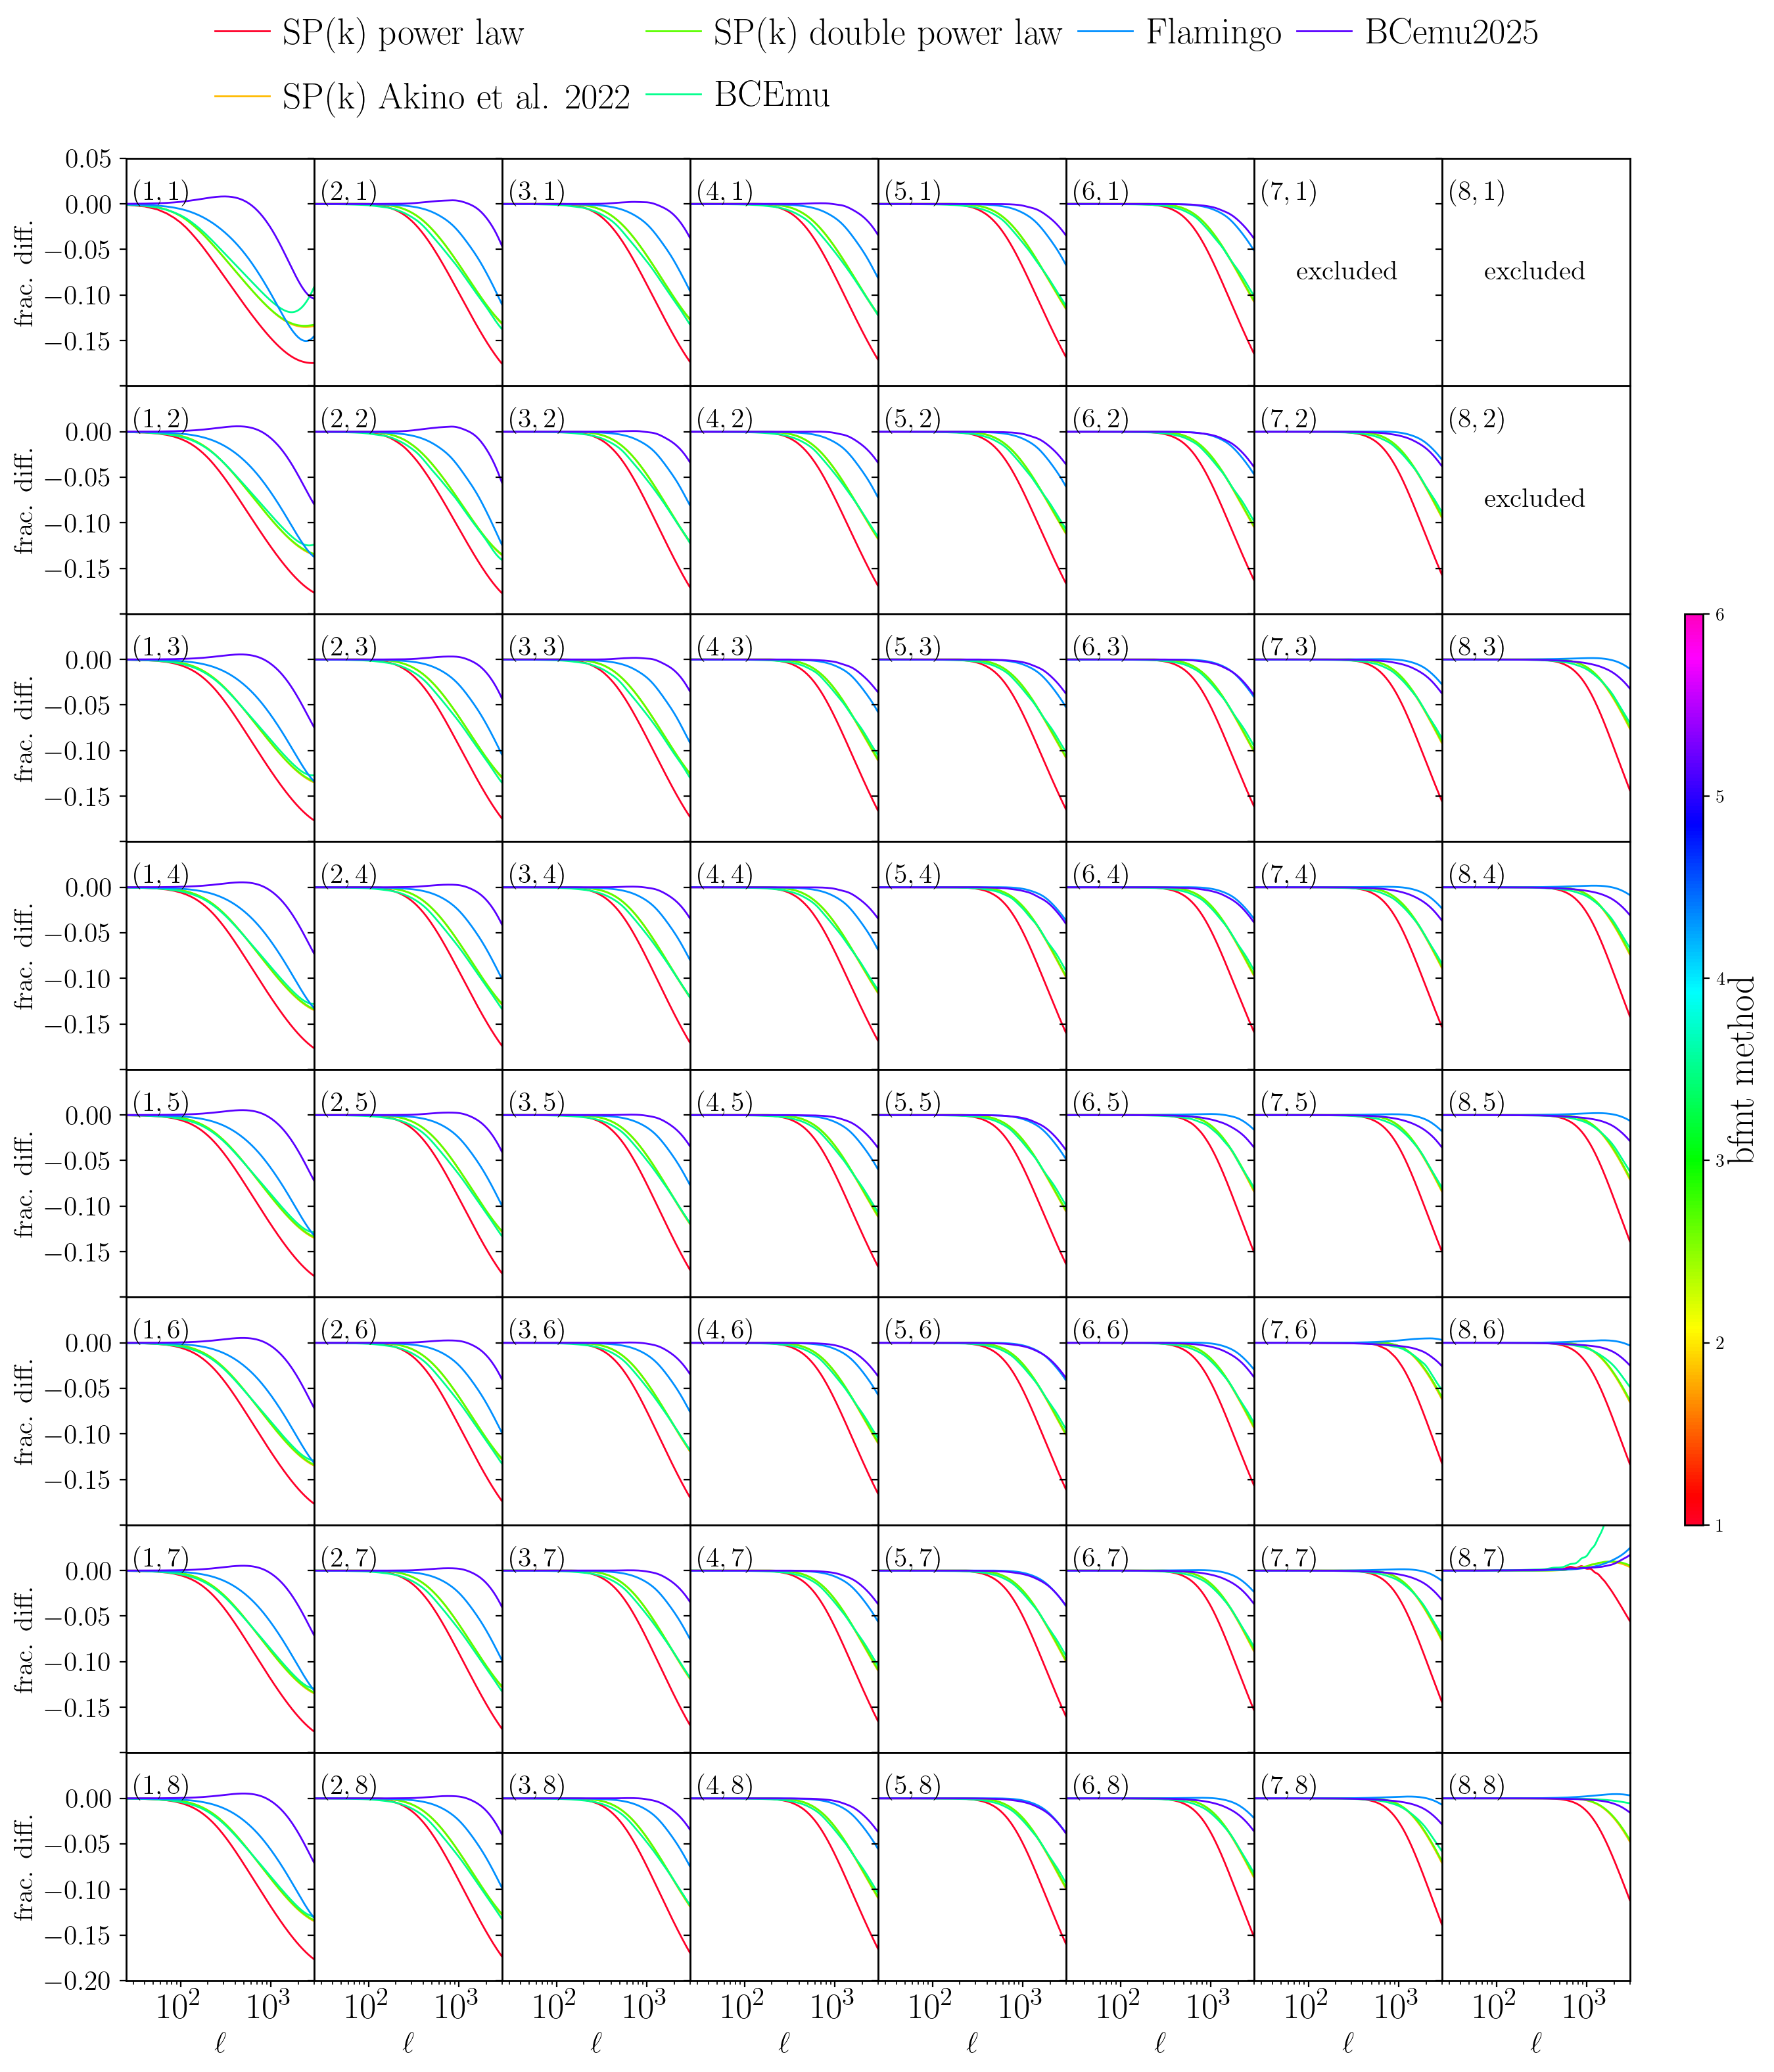

In [15]:
C_gs_list = [results[label]["C_gs"] for label in labels]

cnu.plot_C_gs_tomo_limber(ell=ref["ell"],
                          C_gs=C_gs_list,
                          C_gs_ref=ref["C_gs"],
                          param=param,
                          lmin=25,
                          lmax=3000,
                          figsize=(18, 18),
                          ylim=(0.8, 1.05),
                          colorbarlabel="bfmt method",
                          legend=labels,
                          legendfontsize=20,
                          xaxisticklabelsize=20,
                          yaxisticklabelsize=15,
                          yaxislabelsize=15)

# Galaxy-galaxy lensing with feedback: $\gamma_t(\theta)$ (real space)

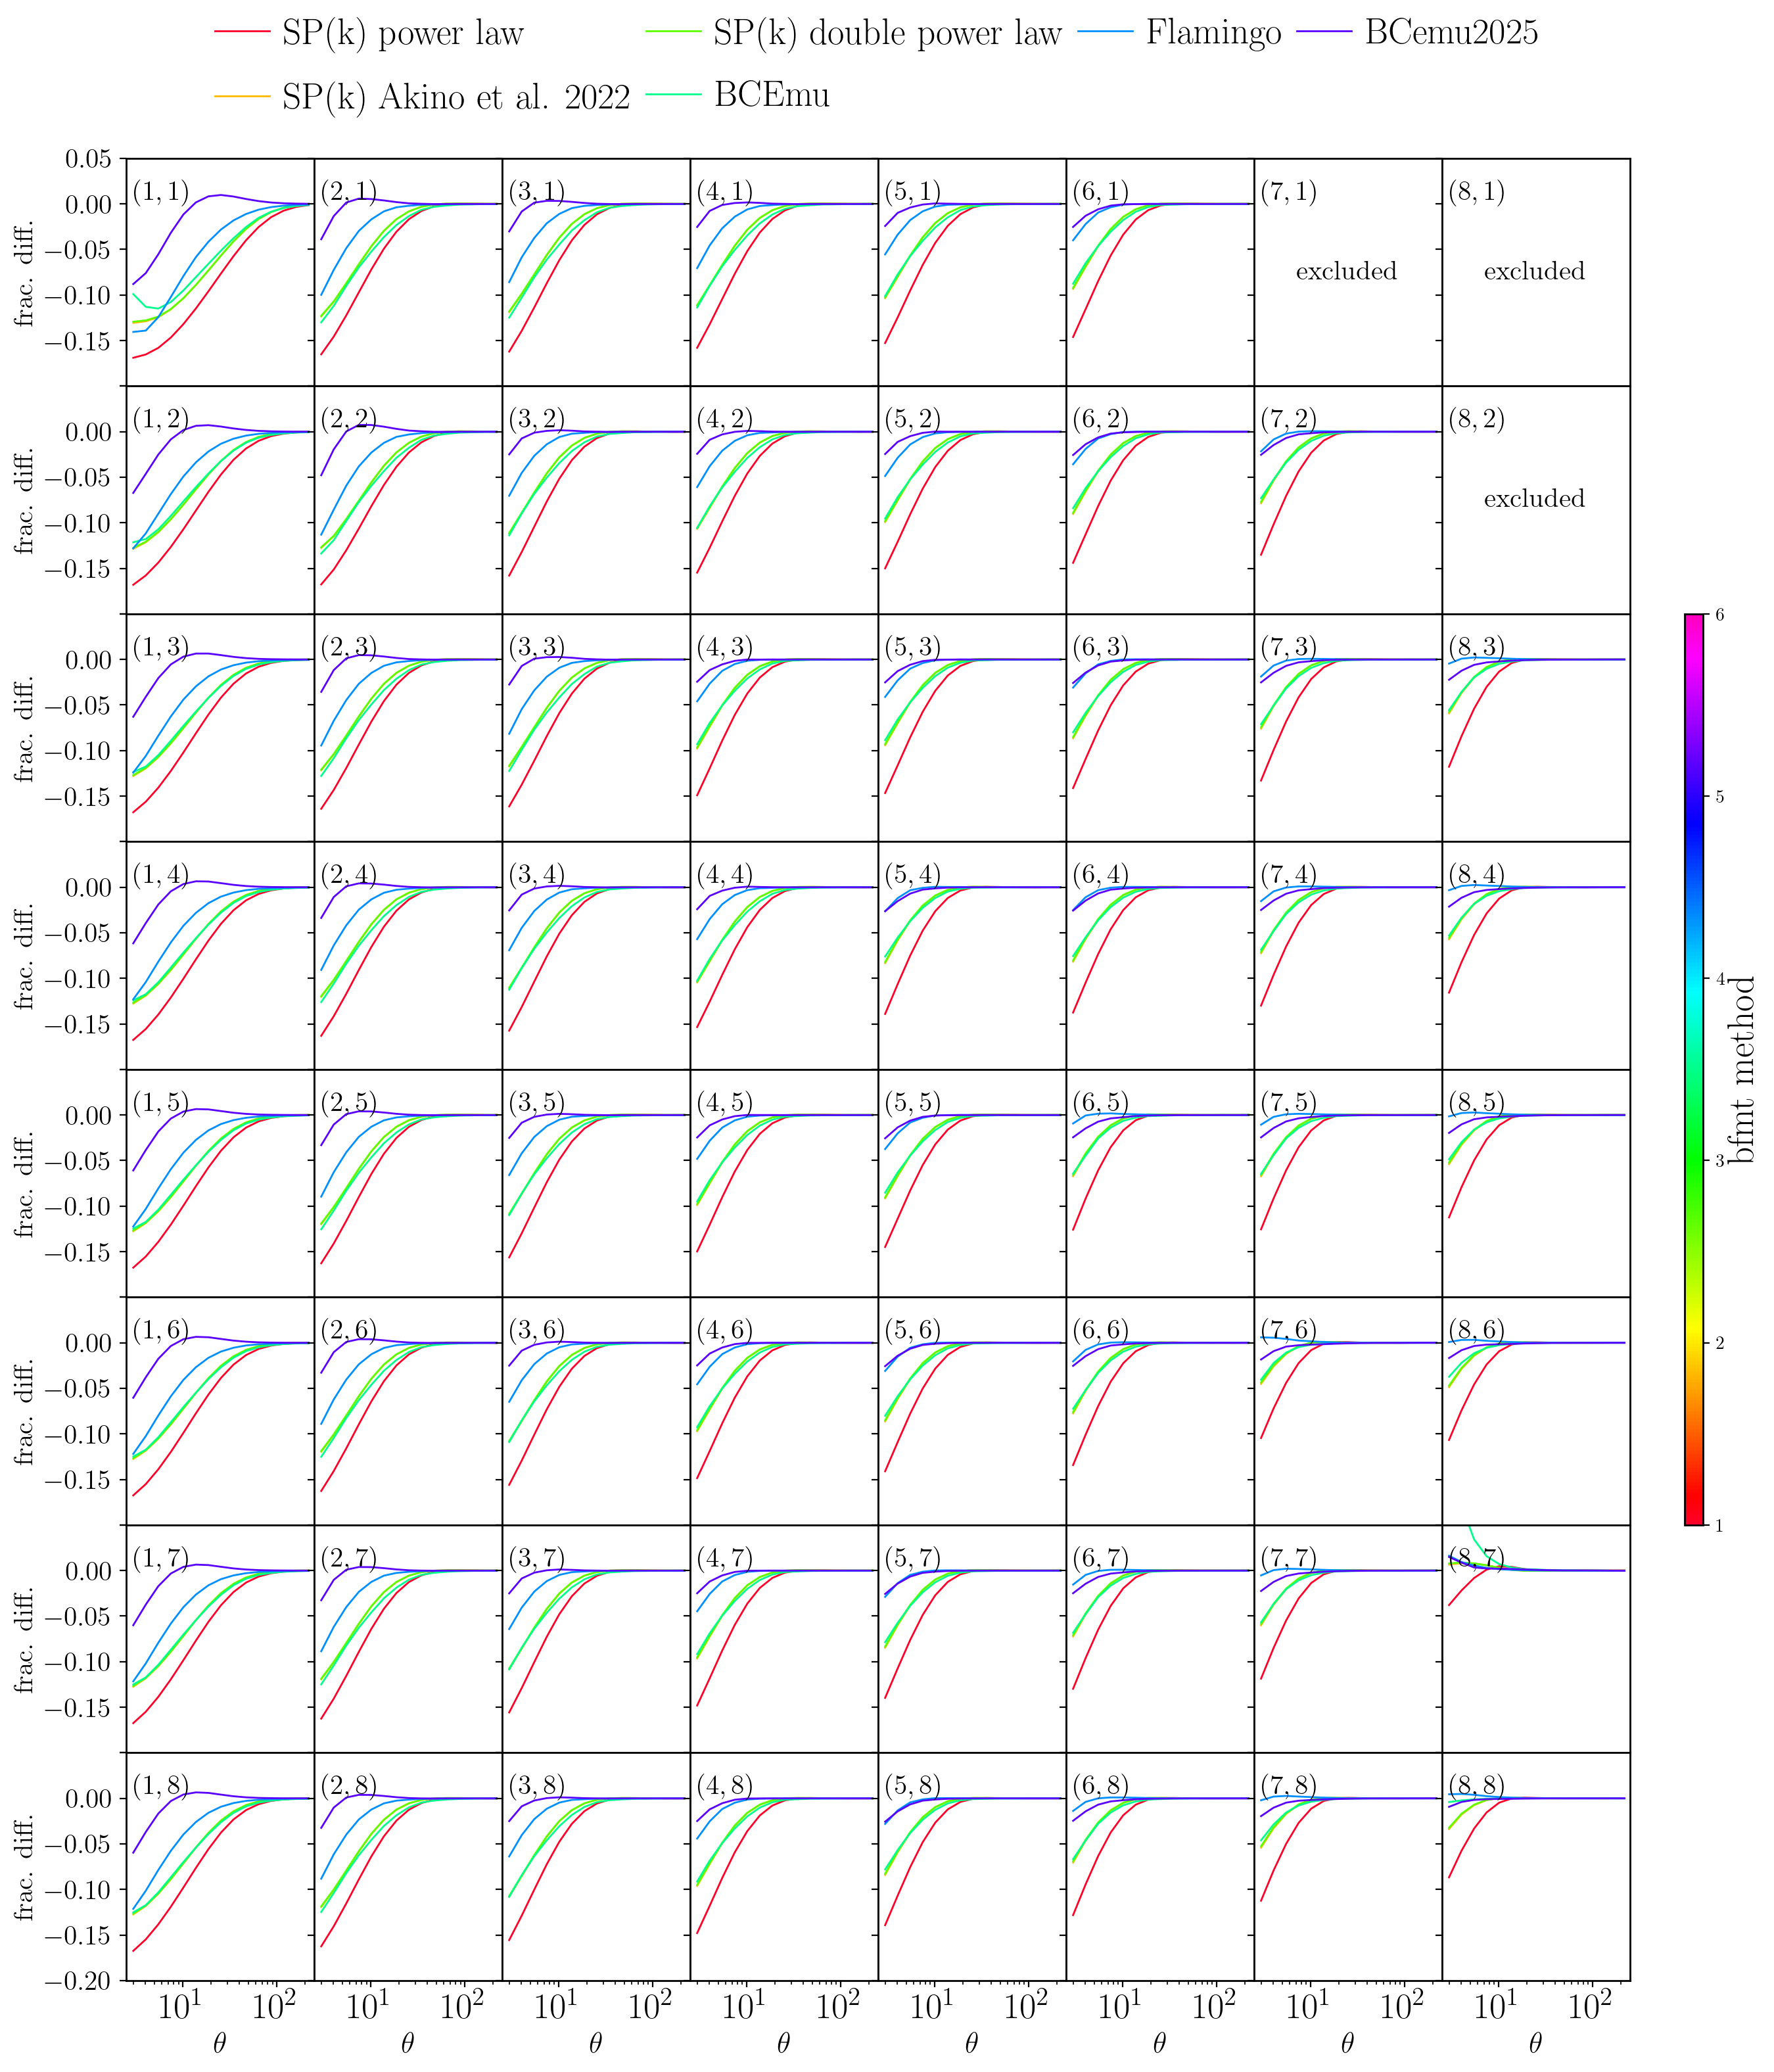

In [17]:
gammat_list = [(results[label]["theta"], results[label]["gammat"])
               for label in labels]
gammat_ref = (ref["theta"], ref["gammat"])
cnu.plot_gammat_tomo_limber(theta_gammat=gammat_list,
                            gammat_ref=gammat_ref,
                            param=param,
                            ylim=(0.8, 1.05),
                            figsize=(18, 18),
                            colorbarlabel="bfmt method",
                            legend=labels,
                            thetashow=[2.5, 250],
                            legendfontsize=20,
                            xaxisticklabelsize=20,
                            yaxisticklabelsize=15,
                            yaxislabelsize=15)

# Vary each method's free parameters, one at a time

Each figure below sweeps a single parameter of one feedback method,
holding everything else at the method's fiducial point, and shows the
suppression $S(k) = P_{\rm feedback}/P_{\rm DM}$ at $z = 0$ (solid) and
$z = 1$ (dashed). The sweep ranges sit inside the bfmt validation boxes
(the 3$\sigma$ boxes of the yaml priors for SP(k) Akino, the emulator
training boxes otherwise). An SP(k) curve can revert to unity at a
redshift where the swept parameter pushes the baryon fraction outside
pyspk's calibrated band — that is the block's documented fallback, not a
bug. Every value is one `get_baryon_suppression` call (a fresh CAMB run),
so this section evaluates CAMB ~130 times and takes tens of minutes.

In [ ]:
# The sweep grid: two redshifts are enough to see the evolution, and
# the k grid spans the scales where feedback acts (1/Mpc, the unit the
# likelihoods send). SWEEP_RESULTS keeps every computed sweep, so a
# figure can be replotted without recomputing.
z_sweep = [0.0, 1.0]
log10k_sweep = np.linspace(-1.3, 1.1, 120)
SWEEP_RESULTS = {}
METHODS_BY_LABEL = {label: (options, point)
                    for label, options, point in BARYON_METHODS}

PARAM_SWEEPS = {
    # loose boxes; the hard guard is pyspk's calibrated fb band
    "SP(k) power law": {
        "fb_a_spk":   [0.2, 0.3, 0.4, 0.5, 0.6],
        "fb_pow_spk": [0.1, 0.2, 0.3, 0.4, 0.5],
    },
    # 3-sigma boxes: alpha 3.8-4.6, beta 1.0-1.6, gamma 0.1-0.75
    "SP(k) Akino et al. 2022": {
        "alpha_spk": [3.9, 4.05, 4.189, 4.35, 4.5],
        "beta_spk":  [1.05, 1.16, 1.273, 1.4, 1.55],
        "gamma_spk": [0.15, 0.22, 0.298, 0.45, 0.6],
    },
    # centered on the in-band point of the methods table above
    "SP(k) double power law": {
        "epsilon_spk": [0.50, 0.58, 0.66, 0.74, 0.82],
        "alpha_spk":   [0.15, 0.25, 0.35, 0.45, 0.55],
        "beta_spk":    [0.10, 0.15, 0.20, 0.25, 0.30],
        "gamma_spk":   [0.10, 0.20, 0.30, 0.40, 0.50],
    },
    # inside the Giri et al. 2021 training box
    "BCEmu": {
        "log10Mc_bcemu": [12.5, 13.0, 13.32, 13.8, 14.3],
        "mu_bcemu":      [0.3, 0.6, 0.93, 1.3, 1.7],
        "thej_bcemu":    [2.5, 3.3, 4.235, 5.3, 6.5],
        "gamma_bcemu":   [1.5, 1.9, 2.25, 2.8, 3.5],
        "delta_bcemu":   [4.0, 5.2, 6.4, 7.7, 9.0],
        "eta_bcemu":     [0.08, 0.11, 0.15, 0.25, 0.35],
        "deta_bcemu":    [0.08, 0.11, 0.14, 0.25, 0.35],
    },
    # the Schaller et al. 2025 suite spans fgas -8sigma..+2sigma,
    # mstar -1sigma, and jet fractions 0..1
    "Flamingo": {
        "fgas_sigma_flamingo":  [-8.0, -4.0, -2.0, 0.0, 2.0],
        "mstar_sigma_flamingo": [-1.0, -0.5, 0.0, 0.5, 1.0],
        "jet_frac_flamingo":    [0.0, 0.25, 0.5, 0.75, 1.0],
    },
    # inside the BCemu2025 training LHC box
    "BCemu2025": {
        "Theta_co_bcemu25": [0.1, 0.2, 0.3, 0.45, 0.6],
        "log10Mc_bcemu25":  [12.0, 12.6, 13.1, 13.7, 14.4],
        "mu_bcemu25":       [0.4, 0.7, 1.0, 1.5, 2.0],
        "delta_bcemu25":    [3.0, 4.5, 6.0, 8.0, 10.0],
        "eta_bcemu25":      [-0.15, -0.05, 0.02, 0.10, 0.18],
        "deta_bcemu25":     [0.05, 0.12, 0.22, 0.30, 0.38],
        "Nstar_bcemu25":    [0.010, 0.019, 0.028, 0.037, 0.045],
    },
}

def sweep_parameter(label, name, values):
    """One-at-a-time sweep: name takes each value, the rest stay at
    the method's fiducial point; returns one (n_z, n_k) array per
    value and caches them in SWEEP_RESULTS."""
    options, fiducial = METHODS_BY_LABEL[label]
    sups = []
    for v in values:
        point = dict(fiducial, **{name: v})
        S = get_baryon_suppression(options, point, z_sweep, log10k_sweep)
        sups.append(np.array([S[z] for z in z_sweep]))
        print(f"  {label}: {name} = {v} done", flush=True)
    SWEEP_RESULTS.setdefault(label, {})[name] = sups
    return sups

def plot_sweeps(label):
    for name, values in PARAM_SWEEPS[label].items():
        sups = sweep_parameter(label, name, values)
        cnu.plot_baryon_suppression(log10k=log10k_sweep,
                                    sup=sups,
                                    param=np.array(values),
                                    colorbarlabel=name.replace("_", " "),
                                    zlabels=["$z=0$", "$z=1$"],
                                    ylim=(0.6, 1.35),
                                    title=label + ": vary " + name.replace("_", " "))

In [ ]:
plot_sweeps("SP(k) power law")

In [ ]:
plot_sweeps("SP(k) Akino et al. 2022")

In [ ]:
plot_sweeps("SP(k) double power law")

In [ ]:
plot_sweeps("BCEmu")

In [ ]:
plot_sweeps("Flamingo")

In [ ]:
plot_sweeps("BCemu2025")